# Target Region Graphics

Compute distance-to-target-region summaries and plots from Capybara synthetic results.

The notebook reads the checkpoint/results table, computes target-region distances for each dataset, writes summary files, and displays the generated figures.

## Setup

Edit the configuration cell below before running if you want a different input file, point source, cost label, or R3 bounds.

In [7]:
import sys
from pathlib import Path

# Locate the repository root so the notebook runs from any working directory
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "synthetic_datasets.py").exists())
sys.path.insert(0, str(REPO_ROOT))
from synthetic_datasets import list_synthetic_datasets, synthetic_metadata

import math
import re
from pathlib import Path
from IPython.display import Image, display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Polygon


# R1: high cospeciation / low host-switch.
# R2: high host-switch / low cospeciation.
# R3 is configured in the notebook configuration cell.

REGIME_TO_REGION = {
    "high_cosp": "R1",
    "low_switch": "R1",
    "high_switch": "R2",
    "medium": "R3",
}

GENERATOR_STYLE = {
    "asymmetree": {"color": "#0072B2", "marker": "o"},
    "coala": {"color": "#E69F00", "marker": "s"},
    "cophylo": {"color": "#009E73", "marker": "^"},
    "treeducken": {"color": "#CC79A7", "marker": "x"},
}

OBSERVED_FREQ_RX = re.compile(
    r"\[(?P<c>[0-9.eE+\-]+)\s*,\s*(?P<s>[0-9.eE+\-]+)\]\s+of\s+size\s+(?P<size>\d+)"
)

FREQUENCY_RX = re.compile(r"#Frequencies\s*:\s*\[([^\]]+)\]")
NUMBER_RX = r"([0-9.eE+\-]+)"


def parse_synthetic_event_frequencies(file_path: Path) -> dict:
    text = (REPO_ROOT / file_path).read_text(encoding="utf-8", errors="ignore")
    generator = synthetic_metadata(file_path)[0]

    def _get(pattern: str):
        matches = re.findall(pattern, text, flags=re.I | re.M)
        if not matches:
            return None
        value = matches[-1]
        if isinstance(value, tuple):
            value = next((v for v in value if v), None)
        try:
            return float(value)
        except (TypeError, ValueError):
            return None

    if generator == "asymmetree":
        speciation = _get(rf"^\s*Speciation\s*:\s*{NUMBER_RX}\s*$")
        duplication = _get(rf"^\s*Duplication\s*:\s*{NUMBER_RX}\s*$")
        loss = _get(rf"^\s*Loss\s*:\s*{NUMBER_RX}\s*$")
        transfer = _get(rf"^\s*Horizontal Gene Transfer\s*:\s*{NUMBER_RX}\s*$")
        raw_counts = [speciation, duplication, transfer, loss]
        if any(v is not None for v in raw_counts):
            counts = [0.0 if v is None else v for v in raw_counts]
            total = sum(counts[:3])
            if total > 0:
                speciation, duplication, transfer, loss = counts
                return {
                    "cosp_freq": speciation / total,
                    "dup_freq": duplication / total,
                    "switch_freq": transfer / total,
                    "loss_freq": loss / total,
                    "raw_speciation_count": speciation,
                    "raw_duplication_count": duplication,
                    "raw_switch_count": transfer,
                    "raw_loss_count": loss,
                    "frequency_source": "counts_non_loss_denominator",
                }

    if generator == "coala":
        match = FREQUENCY_RX.search(text)
        if match:
            try:
                values = [float(x.strip()) for x in match.group(1).split(",")]
                if len(values) >= 4:
                    cosp, duplication, switch, loss = values[:4]
                    return {
                        "cosp_freq": cosp,
                        "dup_freq": duplication,
                        "switch_freq": switch,
                        "loss_freq": loss,
                        "frequency_source": "direct_frequency_vector",
                    }
            except ValueError:
                pass

    if generator == "cophylo":
        cosp = _get(rf"Cospeciation\s*=\s*{NUMBER_RX}")
        switch = _get(rf"Host_switch\s*=\s*{NUMBER_RX}")
    elif generator == "treeducken":
        cosp = _get(rf"Cospeciations\s+{NUMBER_RX}")
        switch = _get(rf"Host_Spreads/switches\s+{NUMBER_RX}")
    else:
        cosp = _get(rf"Cospeciations?\s*(?:=|:)??\s+{NUMBER_RX}")
        switch = (
            _get(rf"Host_Spreads/switches\s+{NUMBER_RX}")
            or _get(rf"Host_switch\s*=\s*{NUMBER_RX}")
            or _get(rf"Horizontal Gene Transfer\s*:\s*{NUMBER_RX}")
        )

    return {
        "cosp_freq": cosp,
        "dup_freq": None,
        "switch_freq": switch,
        "loss_freq": None,
        "frequency_source": "direct_cosp_switch_frequency",
    }


def build_synthetic_frequency_table() -> pd.DataFrame:
    # Dataset folders of each generator/regime are listed in synthetic_datasets.py
    rows = []
    for dataset_path, generator, regime in list_synthetic_datasets():
        row = {
            "dataset_path": str(dataset_path),
            "generator": generator,
            "regime": regime,
            "file_name": dataset_path.name,
        }
        row.update(parse_synthetic_event_frequencies(dataset_path))
        row["real_cosp_freq"] = row.get("cosp_freq")
        row["real_switch_freq"] = row.get("switch_freq")
        rows.append(row)
    return pd.DataFrame(rows)


def load_results(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)

    if path.suffix.lower() in {".xlsx", ".xls"}:
        sheets = pd.read_excel(path, sheet_name=None)
        frames = []
        for sheet_name, frame in sheets.items():
            if frame.empty or "dataset_path" not in frame.columns:
                continue
            frame = frame.copy()
            frame["source_sheet"] = sheet_name
            frames.append(frame)
        if not frames:
            return pd.DataFrame()
        return pd.concat(frames, ignore_index=True)

    raise ValueError(f"Unsupported input type: {path}")


def observed_from_closest(value: object) -> tuple[float | None, float | None, int | None]:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None, None, None
    match = OBSERVED_FREQ_RX.search(str(value))
    if not match:
        return None, None, None
    return float(match.group("c")), float(match.group("s")), int(match.group("size"))


def prepare_points(results_df: pd.DataFrame, point_source: str, cost_label: str | None) -> pd.DataFrame:
    df = results_df.copy()
    if cost_label is not None and "cost_label" in df.columns:
        df = df[df["cost_label"] == cost_label].copy()

    if point_source == "real":
        required = ["dataset_path", "generator", "regime", "real_cosp_freq", "real_switch_freq"]
        missing = [column for column in required if column not in df.columns]
        if missing:
            raise ValueError(f"Missing required columns for real points: {missing}")
        points = df[required].drop_duplicates("dataset_path").copy()
        points["observed_c"] = pd.to_numeric(points["real_cosp_freq"], errors="coerce")
        points["observed_s"] = pd.to_numeric(points["real_switch_freq"], errors="coerce")
        points["observed_size"] = np.nan
        return points.dropna(subset=["observed_c", "observed_s"])

    required = ["dataset_path", "generator", "regime", "cost_label", "closest_observed_frequency"]
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for closest_observed points: {missing}")
    parsed = df["closest_observed_frequency"].apply(observed_from_closest)
    df[["observed_c", "observed_s", "observed_size"]] = pd.DataFrame(parsed.tolist(), index=df.index)
    return df.dropna(subset=["observed_c", "observed_s"]).copy()


def region_rectangle(region: str) -> list[tuple[float, float]]:
    if region == "R1":
        bounds = (0.50, 1.00, 0.00, 0.10)
    elif region == "R2":
        bounds = (0.00, 0.25, 0.40, 1.00)
    elif region == "R3":
        bounds = (R3_C_MIN, R3_C_MAX, R3_S_MIN, R3_S_MAX)
    else:
        return []
    xmin, xmax, ymin, ymax = bounds
    return [(xmin, ymin), (xmax, ymin), (xmax, ymax), (xmin, ymax)]


def feasible_region_polygon(region: str) -> list[tuple[float, float]]:
    """Clip the region rectangle to the frequency simplex c + s <= 1."""
    polygon = region_rectangle(region)
    if not polygon:
        return []
    clipped = []
    for start, end in zip(polygon, polygon[1:] + polygon[:1]):
        start_inside = start[0] + start[1] <= 1.0 + 1e-12
        end_inside = end[0] + end[1] <= 1.0 + 1e-12
        if start_inside:
            clipped.append(start)
        if start_inside != end_inside:
            dx, dy = end[0] - start[0], end[1] - start[1]
            t = (1.0 - start[0] - start[1]) / (dx + dy)
            clipped.append((start[0] + t * dx, start[1] + t * dy))
    return clipped


def _point_segment_distance(px, py, ax, ay, bx, by) -> float:
    dx, dy = bx - ax, by - ay
    if dx == 0 and dy == 0:
        return math.hypot(px - ax, py - ay)
    t = max(0.0, min(1.0, ((px - ax) * dx + (py - ay) * dy) / (dx * dx + dy * dy)))
    return math.hypot(px - (ax + t * dx), py - (ay + t * dy))


def distance_to_region(c: float, s: float, region: str) -> float:
    polygon = feasible_region_polygon(region)
    if not polygon:
        return np.nan
    # The feasible polygons are convex and counter-clockwise.
    crosses = []
    for a, b in zip(polygon, polygon[1:] + polygon[:1]):
        crosses.append((b[0] - a[0]) * (s - a[1]) - (b[1] - a[1]) * (c - a[0]))
    if all(value >= -1e-12 for value in crosses):
        return 0.0
    return min(
        _point_segment_distance(c, s, a[0], a[1], b[0], b[1])
        for a, b in zip(polygon, polygon[1:] + polygon[:1])
    )


def add_region_distances(points_df: pd.DataFrame) -> pd.DataFrame:
    df = points_df.copy()
    df["generator"] = df["generator"].astype(str).str.strip().str.lower()
    df["regime"] = df["regime"].astype(str).str.strip().str.lower()
    df["target_region"] = df["regime"].map(REGIME_TO_REGION)
    df["distance_to_region"] = [
        distance_to_region(c, s, region)
        for c, s, region in zip(df["observed_c"], df["observed_s"], df["target_region"])
    ]
    df["inside_region"] = df["distance_to_region"].eq(0)
    return df


def iqr(series: pd.Series) -> float:
    return series.quantile(0.75) - series.quantile(0.25)


def summarize(points_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (generator, regime), group in points_df.groupby(["generator", "regime"], dropna=False):
        region = group["target_region"].dropna().iloc[0] if group["target_region"].notna().any() else None
        median_c = group["observed_c"].median()
        median_s = group["observed_s"].median()
        centroid_c = group["observed_c"].mean()
        centroid_s = group["observed_s"].mean()
        rows.append(
            {
                "generator": generator,
                "regime": regime,
                "target_region": region,
                "n_datasets": len(group),
                "proportion_inside_region": group["inside_region"].mean(),
                "median_distance_to_region": group["distance_to_region"].median(),
                "iqr_distance_to_region": iqr(group["distance_to_region"]),
                "median_observed_c": median_c,
                "median_observed_s": median_s,
                "centroid_c": centroid_c,
                "centroid_s": centroid_s,
                "median_point_c": median_c,
                "median_point_s": median_s,
                "distance_of_centroid_to_region": distance_to_region(centroid_c, centroid_s, region),
                "distance_of_median_point_to_region": distance_to_region(median_c, median_s, region),
            }
        )
    return pd.DataFrame(rows).sort_values(["generator", "regime"]).reset_index(drop=True)


def draw_region(ax: plt.Axes, region: str) -> None:
    colors = {"R1": "tab:green", "R2": "tab:orange", "R3": "tab:blue"}
    polygon = feasible_region_polygon(region)
    if polygon:
        ax.add_patch(Polygon(polygon, closed=True, alpha=0.14, facecolor=colors[region], edgecolor=colors[region], linewidth=1))
    # Boundary of the feasible frequency simplex.
    ax.plot([0, 1], [1, 0], color="#555555", linestyle="--", linewidth=1, alpha=0.8)


def plot_scatter(points_df: pd.DataFrame, output_path: Path) -> None:
    regions = ["R1", "R2", "R3"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)
    for ax, region in zip(axes, regions):
        draw_region(ax, region)
        subset = points_df[points_df["target_region"] == region]
        for generator, group in subset.groupby("generator"):
            style = GENERATOR_STYLE.get(generator, {"color": "#666666", "marker": "o"})
            ax.scatter(
                group["observed_c"],
                group["observed_s"],
                s=18,
                alpha=0.50,
                label=generator,
                color=style["color"],
                marker=style["marker"],
                edgecolors="none",
            )
        ax.set_title(region)
        ax.set_xlabel("observed cosp frequency")
        ax.grid(alpha=0.2)
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
    axes[0].set_ylabel("observed host-switch frequency")
    handles, labels = axes[-1].get_legend_handles_labels()
    if handles:
        for handle in handles:
            handle.set_alpha(1.0)
            handle.set_sizes([90])
        fig.legend(
            handles, labels, loc="upper center", ncol=min(len(labels), 5),
            frameon=True, fontsize=10, handletextpad=0.7, columnspacing=1.4,
        )
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    fig.savefig(output_path, dpi=200)
    plt.close(fig)


def plot_distance_boxplot(points_df: pd.DataFrame, output_path: Path) -> None:
    df = points_df.copy()
    generator_order = ["coala", "treeducken", "cophylo", "asymmetree"]
    region_order = ["R1", "R2", "R3"]
    generator_labels = {
        "coala": "Coala",
        "treeducken": "TreeDucken",
        "cophylo": "Cophylo",
        "asymmetree": "AsymmeTree",
    }
    ordered_groups = [
        (generator, region)
        for region in region_order
        for generator in generator_order
        if ((df["generator"] == generator) & (df["target_region"] == region)).any()
    ]
    groups = [f"{generator_labels[generator]} / {region.replace('R', 'R_')}" for generator, region in ordered_groups]
    data = [
        df.loc[
            (df["generator"] == generator) & (df["target_region"] == region),
            "distance_to_region",
        ].dropna().to_numpy()
        for generator, region in ordered_groups
    ]

    fig_width = max(10, 0.65 * len(groups))
    fig, ax = plt.subplots(figsize=(fig_width, 5))
    ax.boxplot(data, tick_labels=groups, showfliers=False)
    ax.set_ylabel("distance to target region")
    ax.set_xlabel("generator / target region")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.close(fig)

In [9]:
# Input/output configuration.
# INPUT_PATH = None scans the synthetic datasets (synthetic_datasets.py) and writes
# target_region_outputs/synthetic_dataset_frequencies.{xlsx,csv}.
INPUT_PATH = None
OUTPUT_DIR = Path("target_region_outputs")

# Use "real" for dataset-provided frequencies.
POINT_SOURCE = "real"

# Optional when loading a custom Capybara result file through INPUT_PATH.
# Examples: "classical_1", "classical_3", "transformed"
COST_LABEL = None

# R3 manuscript definition: 0.20 <= c <= 0.40 and 0.20 <= s <= 0.40.
R3_C_MIN = 0.20
R3_C_MAX = 0.40
R3_S_MIN = 0.20
R3_S_MAX = 0.40

## Region Definitions

The script uses:

- `R1`: `c >= 0.50` and `s <= 0.10`
- `R2`: `c <= 0.25` and `s >= 0.40`
- `R3`: `0.20 <= c <= 0.40` and `0.20 <= s <= 0.40`

For each point, the distance is zero if it falls inside the intended region.

In [10]:
if INPUT_PATH is None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    results_df = build_synthetic_frequency_table()
    input_path = OUTPUT_DIR / "synthetic_dataset_frequencies.xlsx"
    frequency_csv_path = OUTPUT_DIR / "synthetic_dataset_frequencies.csv"
    results_df.to_excel(input_path, index=False)
    results_df.to_csv(frequency_csv_path, index=False)
else:
    input_path = INPUT_PATH
    results_df = load_results(input_path)

points_df = prepare_points(results_df, POINT_SOURCE, COST_LABEL)
points_df = add_region_distances(points_df)
summary_df = summarize(points_df)

print(f"Input: {input_path}")
print(f"Rows in raw results: {len(results_df)}")
print(f"Points analyzed: {len(points_df)}")
summary_df

Input: target_region_outputs/synthetic_dataset_frequencies.xlsx
Rows in raw results: 12000
Points analyzed: 12000


,generator,regime,target_region,n_datasets,proportion_inside_region,median_distance_to_region,iqr_distance_to_region,median_observed_c,median_observed_s,centroid_c,centroid_s,median_point_c,median_point_s,distance_of_centroid_to_region,distance_of_median_point_to_region
0,asymmetree,high_switch,R2,1000,0.767,0.000000,0.000000,0.191011,0.556122,0.191287,0.555977,0.191011,0.556122,0.000000,0.000000
1,asymmetree,low_switch,R1,1000,0.713,0.000000,0.013514,0.551724,0.011628,0.546251,0.015386,0.551724,0.011628,0.000000,0.000000
2,asymmetree,medium,R3,1000,0.602,0.000000,0.025585,0.346344,0.313349,0.343835,0.314107,0.346344,0.313349,0.000000,0.000000
3,coala,high_cosp,R1,1000,1.000,0.000000,0.000000,0.800000,0.020000,0.804106,0.021394,0.800000,0.020000,0.000000,0.000000
4,coala,high_switch,R2,1000,1.000,0.000000,0.000000,0.079500,0.580000,0.075986,0.589330,0.079500,0.580000,0.000000,0.000000
5,coala,medium,R3,1000,0.895,0.000000,0.000000,0.306000,0.306000,0.306774,0.305878,0.306000,0.306000,0.000000,0.000000
6,cophylo,high_cosp,R1,1000,1.000,0.000000,0.000000,0.799802,0.025354,0.800304,0.025000,0.799802,0.025354,0.000000,0.000000
7,cophylo,high_switch,R2,1000,1.000,0.000000,0.000000,0.076053,0.600939,0.075742,0.601227,0.076053,0.600939,0.000000,0.000000
8,cophylo,medium,R3,1000,1.000,0.000000,0.000000,0.301274,0.298131,0.301758,0.300848,0.301274,0.298131,0.000000,0.000000
9,treeducken,high_cosp,R1,1000,0.079,0.069963,0.062588,0.430037,0.000000,0.430063,0.004758,0.430037,0.000000,0.069937,0.069963


## Save Tables and Figures

In [12]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

suffix = POINT_SOURCE if COST_LABEL is None else f"{POINT_SOURCE}_{COST_LABEL}"
points_path = OUTPUT_DIR / f"target_region_points_{suffix}.csv"
summary_csv_path = OUTPUT_DIR / f"target_region_summary_{suffix}.csv"
summary_xlsx_path = OUTPUT_DIR / f"target_region_summary_{suffix}.xlsx"
scatter_path = OUTPUT_DIR / f"target_region_scatter_{suffix}.png"
boxplot_path = OUTPUT_DIR / f"target_region_distance_boxplot_{suffix}.png"

points_df.to_csv(points_path, index=False)
summary_df.to_csv(summary_csv_path, index=False)
summary_df.to_excel(summary_xlsx_path, index=False)

plot_scatter(points_df, scatter_path)
plot_distance_boxplot(points_df, boxplot_path)

print(f"Points: {points_path}")
print(f"Summary CSV: {summary_csv_path}")
print(f"Summary Excel: {summary_xlsx_path}")
print(f"Scatter plot: {scatter_path}")
print(f"Distance boxplot: {boxplot_path}")

/var/folders/47/xjfgb9s92xb8_8n05xp14gnm0000gn/T/ipykernel_21963/2392471586.py:308: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/var/folders/47/xjfgb9s92xb8_8n05xp14gnm0000gn/T/ipykernel_21963/2392471586.py:308: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/var/folders/47/xjfgb9s92xb8_8n05xp14gnm0000gn/T/ipykernel_21963/2392471586.py:308: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


Points: target_region_outputs/target_region_points_real.csv
Summary CSV: target_region_outputs/target_region_summary_real.csv
Summary Excel: target_region_outputs/target_region_summary_real.xlsx
Scatter plot: target_region_outputs/target_region_scatter_real.png
Distance boxplot: target_region_outputs/target_region_distance_boxplot_real.png


## Plots

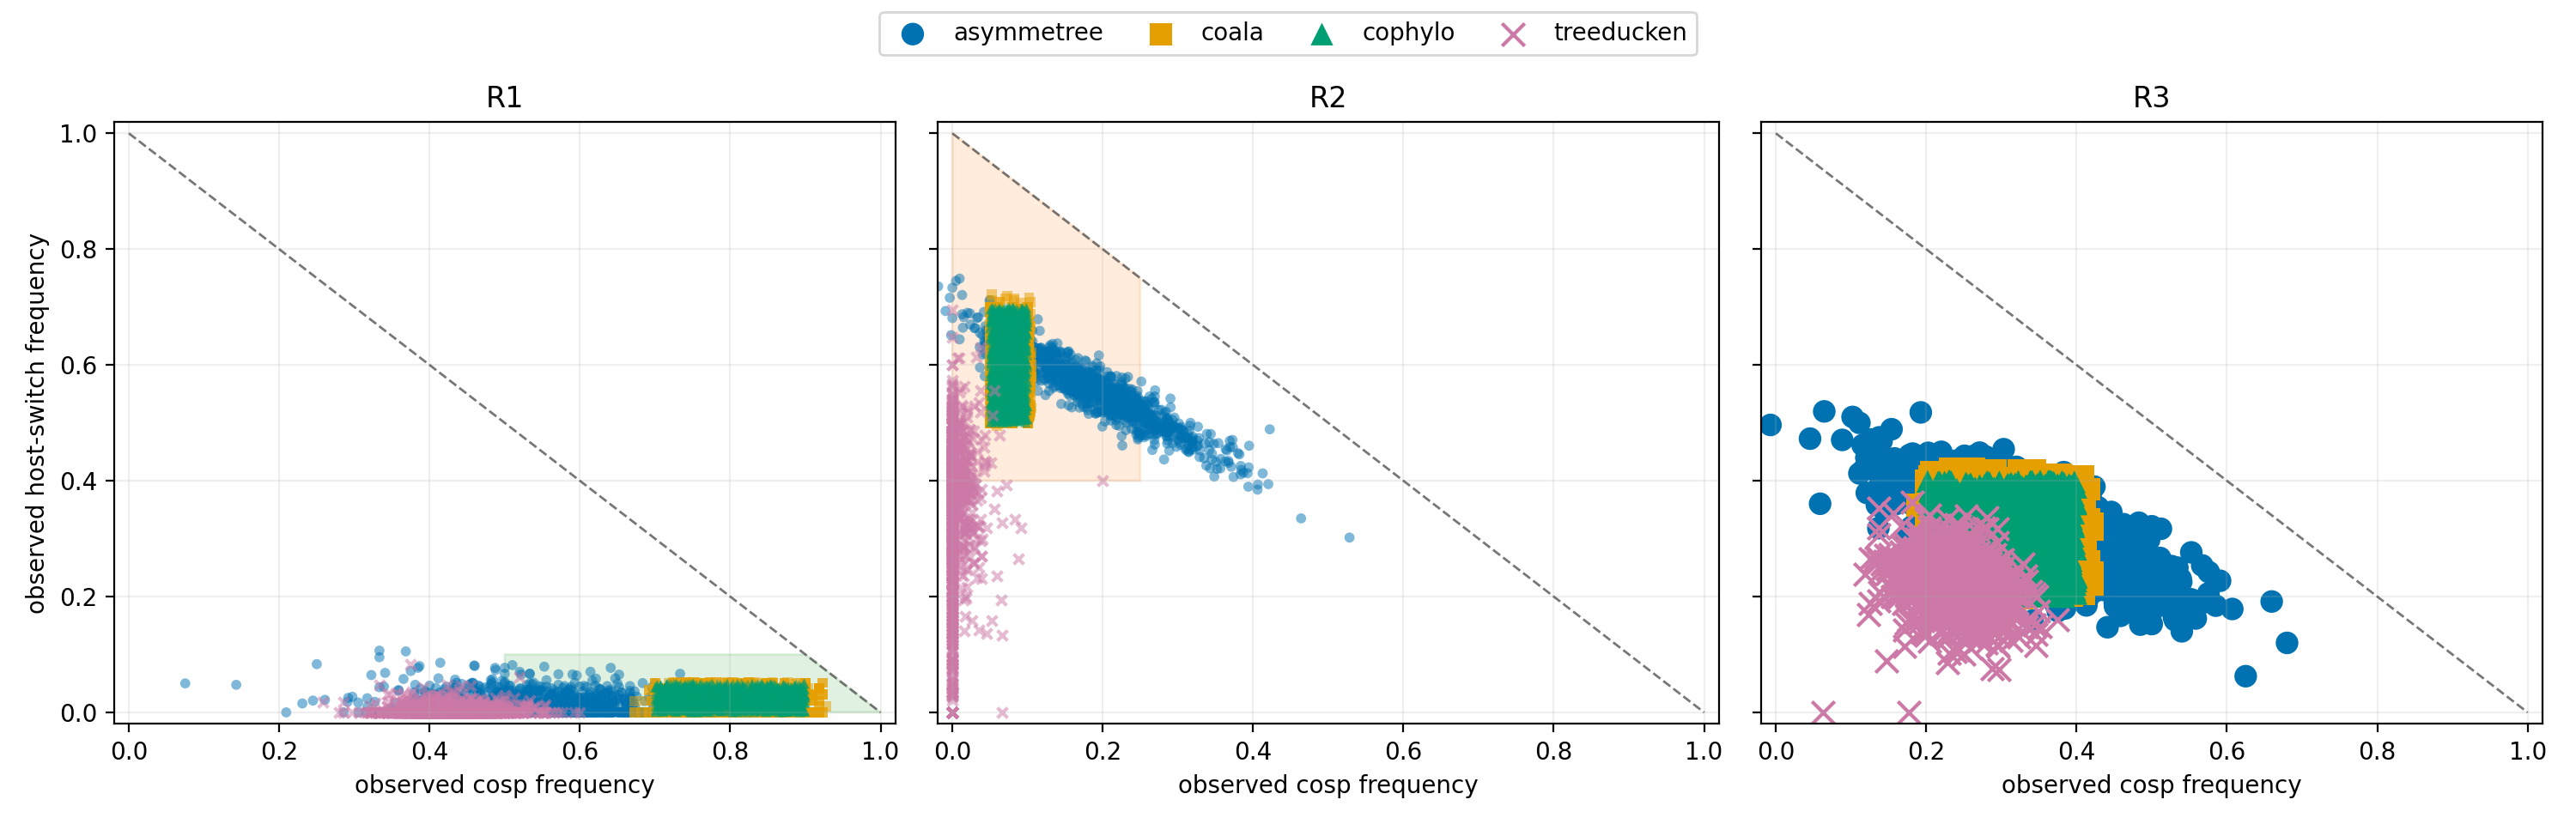

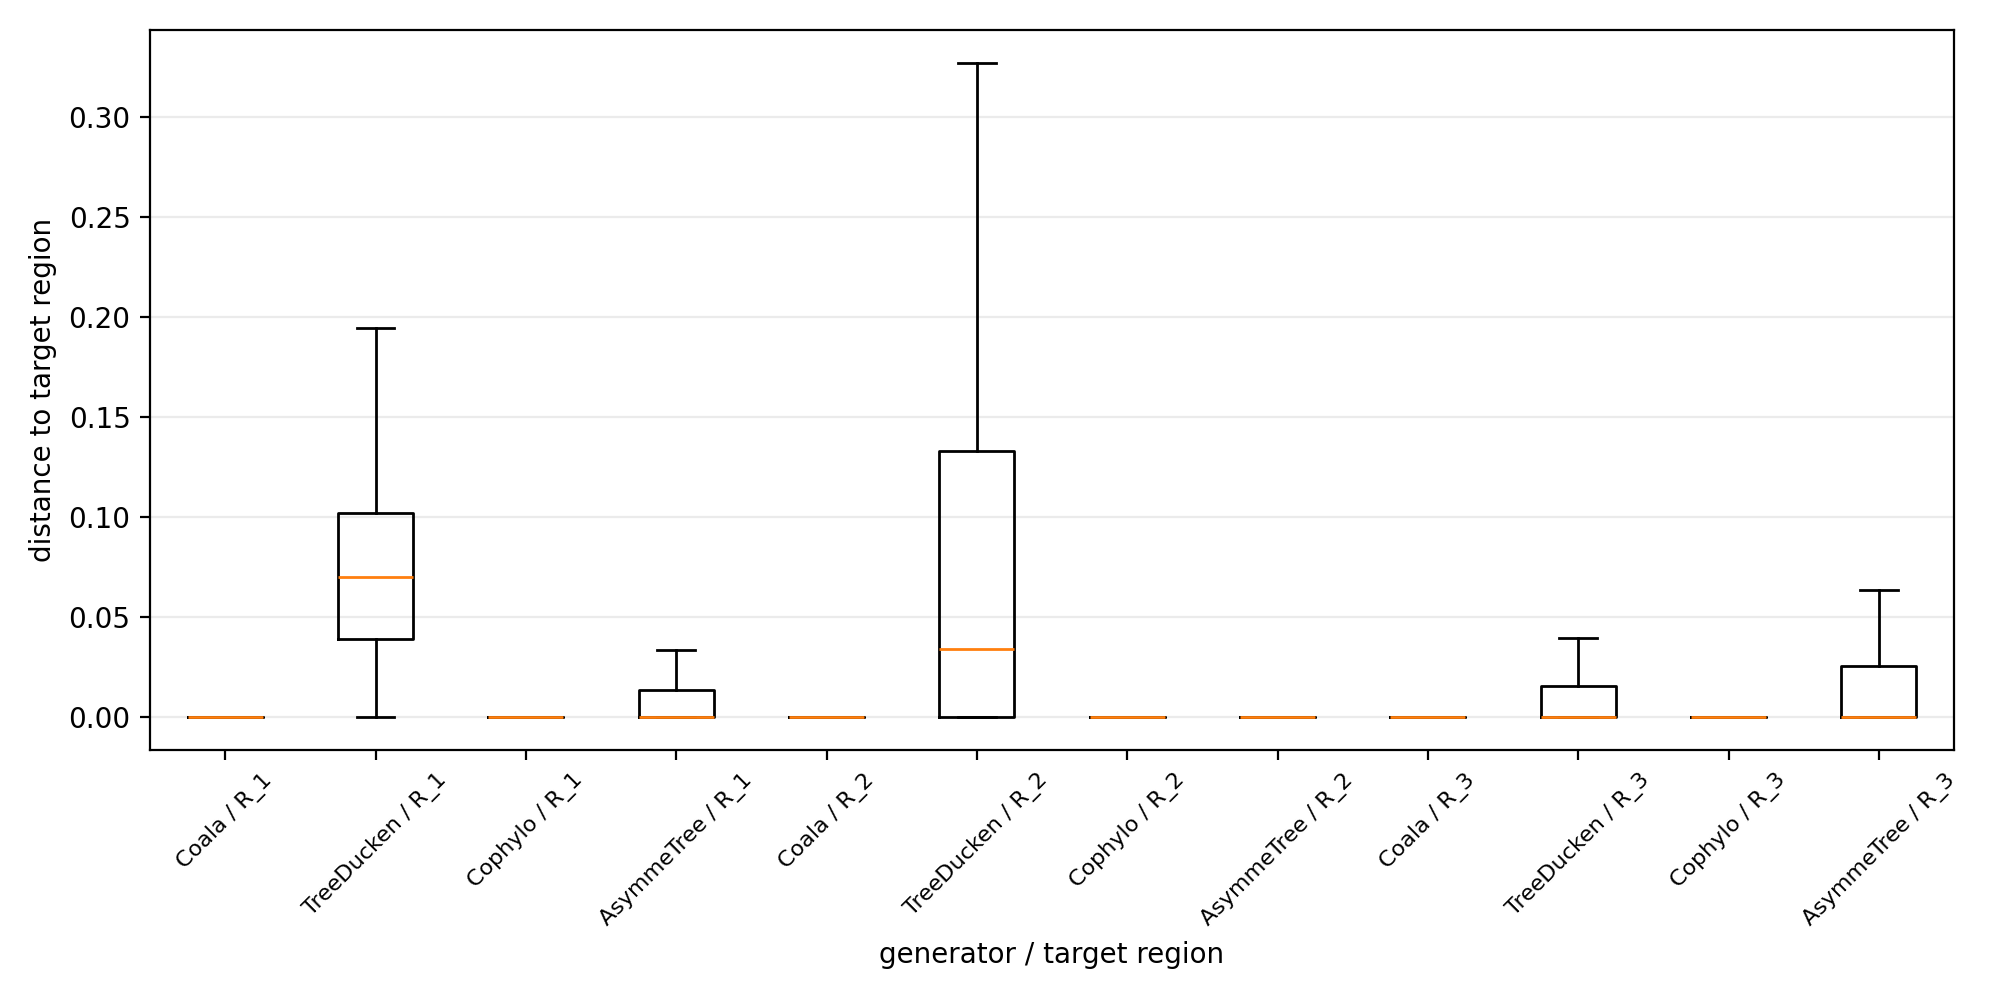

In [15]:
display(Image(filename=str(scatter_path)))
display(Image(filename=str(boxplot_path)))

## Point-Level Data

Use this table if you want to inspect individual dataset distances.

In [16]:
points_df.head(20)

,dataset_path,generator,regime,real_cosp_freq,real_switch_freq,observed_c,observed_s,observed_size,target_region,distance_to_region,inside_region
0,synthetic_data/asymmetree/high_switch/Datasets...,asymmetree,high_switch,0.167260,0.548043,0.167260,0.548043,NaN,R2,0.000000,True
1,synthetic_data/asymmetree/high_switch/Datasets...,asymmetree,high_switch,0.101141,0.627706,0.101141,0.627706,NaN,R2,0.000000,True
2,synthetic_data/asymmetree/high_switch/Datasets...,asymmetree,high_switch,0.262880,0.513871,0.262880,0.513871,NaN,R2,0.012880,False
3,synthetic_data/asymmetree/high_switch/Datasets...,asymmetree,high_switch,0.145078,0.595855,0.145078,0.595855,NaN,R2,0.000000,True
4,synthetic_data/asymmetree/high_switch/Datasets...,asymmetree,high_switch,0.107195,0.609398,0.107195,0.609398,NaN,R2,0.000000,True
5,synthetic_data/asymmetree/high_switch/Datasets...,asymmetree,high_switch,0.186047,0.598007,0.186047,0.598007,NaN,R2,0.000000,True
6,synthetic_data/asymmetree/high_switch/Datasets...,asymmetree,high_switch,0.129241,0.612278,0.129241,0.612278,NaN,R2,0.000000,True
7,synthetic_data/asymmetree/high_switch/Datasets...,asymmetree,high_switch,0.205426,0.554264,0.205426,0.554264,NaN,R2,0.000000,True
8,synthetic_data/asymmetree/high_switch/Datasets...,asymmetree,high_switch,0.212548,0.567222,0.212548,0.567222,NaN,R2,0.000000,True
9,synthetic_data/asymmetree/high_switch/Datasets...,asymmetree,high_switch,0.212389,0.555310,0.212389,0.555310,NaN,R2,0.000000,True
